# **Applied Machine Learning (Basic) Project**
###Andrea Arriola Gamboa
###Bioinformatics
###A.Y. 2024/2025

# Introduction

Breast cancer diagnosis is a high-impact healthcare task where early and accurate detection can significantly improve patient outcomes. This project applies a supervised machine learning workflow to the **[Breast Cancer Wisconsin (Diagnostic)](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic)** dataset from the UCI Machine Learning Repository. The dataset contains 569 biopsy samples described by 30 numerical features computed from cell nuclei in fine needle aspiration (FNA) images, and the goal is binary classification of tumors as malignant or benign.

The project follows a typical applied ML pipeline: data exploration and quality checks, handling moderate class imbalance, analyzing and addressing feature redundancy/correlation among related measurements, and training/evaluating several standard classifiers. Model performance is assessed using stratified cross-validation and clinically relevant metrics (especially recall for malignant cases, given the cost of false negatives). The final model is selected through model comparison and hyperparameter tuning, providing an end-to-end example of how machine learning can support decision-making in a real healthcare classification setting.

## Breast Cancer Wisconsin (Diagnostic) Dataset Features

Each nucleus measurement is reported in **three versions**:
- **`*1` = mean** value for the measurement  
- **`*2` = standard error (SE)** of the measurement  
- **`*3` = “worst”** value (computed from the most extreme measurements, commonly the mean of the **largest 3** values)

### **Base measurements:**
- **radius**: mean distance from center to points on the perimeter  
- **texture**: standard deviation of gray-scale values (image intensity variation)  
- **perimeter**: nucleus perimeter length  
- **area**: nucleus area  
- **smoothness**: local variation in radius lengths (how smooth the boundary is)  
- **compactness**: (perimeter² / area) - 1.0  
- **concavity**: severity of concave portions of the contour  
- **concave_points**: number of concave portions of the contour  
- **symmetry**: symmetry of the nucleus shape  
- **fractal_dimension**: “coastline approximation” (shape complexity)


# Step 0: Setup

Before kicking off, core libraries that are used throughout the notebook (NumPy and pandas for data handling, seaborn and matplotlib for visualization) are imported. A fixed `RANDOM_STATE` is set to make results reproducible (so splits and model behavior stay consistent across runs). Finally, basic plot formatting is established to keep charts readable and consistent.

In [65]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

In [66]:
# Reproducibility
RANDOM_STATE = 47
np.random.seed(RANDOM_STATE)

In [67]:
# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

# Step 1: Load Data

The Breast Cancer Wisconsin (Diagnostic) dataset is downloaded from the UCI Machine Learning Repository following the `ucimlrepo` procedure shown on the dataset website. The data is loaded into pandas DataFrames (`X` containing 569 samples x 30 numeric features, and `y` containing the diagnosis label).

In [68]:
!pip -q install ucimlrepo
from ucimlrepo import fetch_ucirepo
import pandas as pd

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# metadata
print(breast_cancer_wisconsin_diagnostic.metadata)
print("\n")

# variable information
print(breast_cancer_wisconsin_diagnostic.variables)

{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

Basic checks are performed by printing shapes and previewing the first rows. Since `y` is initially a one-column DataFrame, it is converted into a Series (`y_series`) to inspect the class labels and counts, and then mapped to a numeric target (`target`, with malignant=1 and benign=0) to make it compatible with scikit-learn models.

In [69]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (569, 30)
y shape: (569, 1)


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [70]:
# Convert y from df to a Series
y_series = y.iloc[:, 0].rename("diagnosis")

print("Target labels:", y_series.unique())
print("\nClass counts:")
print(y_series.value_counts())

# Numeric target for scikit-learn
# malignant=1, benign=0
y_bin = y_series.map({"M": 1, "B": 0}).astype(int)

print("\nNumeric class counts (1=malignant, 0=benign):")
print(y_bin.value_counts())

Target labels: ['M' 'B']

Class counts:
diagnosis
B    357
M    212
Name: count, dtype: int64

Numeric class counts (1=malignant, 0=benign):
diagnosis
0    357
1    212
Name: count, dtype: int64


# Step 2: Explore Data

**Exploratory Data Analysis (EDA)** is an early and essential step in a machine learning project because it helps understand the dataset before modelling. It is used to check data quality, inspect feature distributions and scales, evaluate class balance, and identify correlations between variables. These insights guide later preprocessing and modelling choices, such as scaling, feature selection, and evaluation strategy.

In order to begin with the EDA, the dataset is consolidated into a single pandas DataFrame (`df`) by combining the feature matrix (`X`) with both the original diagnosis labels (`diagnosis`) and the numeric target (`target`).


In [71]:
# DataFrame for Step 2:
df = X.copy()
df["diagnosis"] = y_series
df["target"] = y_bin

df.head()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,diagnosis,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M,1


The data is first explored through basic structure and quality checks to ensure it is suitable for modelling. Missing values are inspected because many machine learning algorithms cannot handle NaNs directly, and unaddressed missing data can bias results. Duplicate rows are also checked to avoid training and evaluating the model on repeated observations. In addition, data types are verified to confirm that all predictors are numerical and that the label columns are correctly formatted. Finally, the diagnosis and target counts are printed as a sanity check to confirm the class distribution and the correct mapping from the original labels (B/M) to the numeric target (0/1).

In [72]:
# Check duplicates
print("Duplicates:", df.duplicated().sum())
# Check missing values
print("Total missing:", df.isnull().sum().sum())
# Check feature types
print("\nDtype counts:\n", df.dtypes.value_counts())
# Check labels
print("\nDiagnosis counts:\n", df["diagnosis"].value_counts())
print("\nTarget counts:\n", df["target"].value_counts())

Duplicates: 0
Total missing: 0

Dtype counts:
 float64    30
object      1
int64       1
Name: count, dtype: int64

Diagnosis counts:
 diagnosis
B    357
M    212
Name: count, dtype: int64

Target counts:
 target
0    357
1    212
Name: count, dtype: int64


Then, a statistics summary is computed only on the numerical predictors, so the categorical label (`diagnosis`) and the target (`target`) are dropped. These columns are not input features and including them would either produce meaningless statistics or mix the outcome variable into the feature summary. Keeping the descriptive analysis focused on the predictors helps reveal the typical ranges, variability, and potential outliers of the features that will actually be used by the models.

In [73]:
# Statistics summary
df.drop(columns=["diagnosis", "target"]).describe(percentiles=[.10, .25, .50, .75, .90]).transpose()

,count,mean,std,min,10%,25%,50%,75%,90%,max
radius1,569.0,14.127292,3.524049,6.981000,10.260000,11.700000,13.370000,15.780000,19.530000,28.11000
texture1,569.0,19.289649,4.301036,9.710000,14.078000,16.170000,18.840000,21.800000,24.992000,39.28000
perimeter1,569.0,91.969033,24.298981,43.790000,65.830000,75.170000,86.240000,104.100000,129.100000,188.50000
area1,569.0,654.889104,351.914129,143.500000,321.600000,420.300000,551.100000,782.700000,1177.400000,2501.00000
smoothness1,569.0,0.096360,0.014064,0.052630,0.079654,0.086370,0.095870,0.105300,0.114820,0.16340
compactness1,569.0,0.104341,0.052813,0.019380,0.049700,0.064920,0.092630,0.130400,0.175460,0.34540
concavity1,569.0,0.088799,0.079720,0.000000,0.013686,0.029560,0.061540,0.130700,0.203040,0.42680
concave_points1,569.0,0.048919,0.038803,0.000000,0.011158,0.020310,0.033500,0.074000,0.100420,0.20120
symmetry1,569.0,0.181162,0.027414,0.106000,0.149580,0.161900,0.179200,0.195700,0.214940,0.30400
fractal_dimension1,569.0,0.062798,0.007060,0.049960,0.055338,0.057700,0.061540,0.066120,0.072266,0.09744


The next step is to check class balance. This is important because if one class is more frequent than the other, a model can appear to perform well by mostly predicting the majority class, while failing on the minority class. In a medical setting this matters even more, since the minority class often represents the disease and missing positive cases can be costly. For this reason, inspecting the class distribution helps guide the evaluation strategy and determines whether additional imbalance-handling techniques are needed.

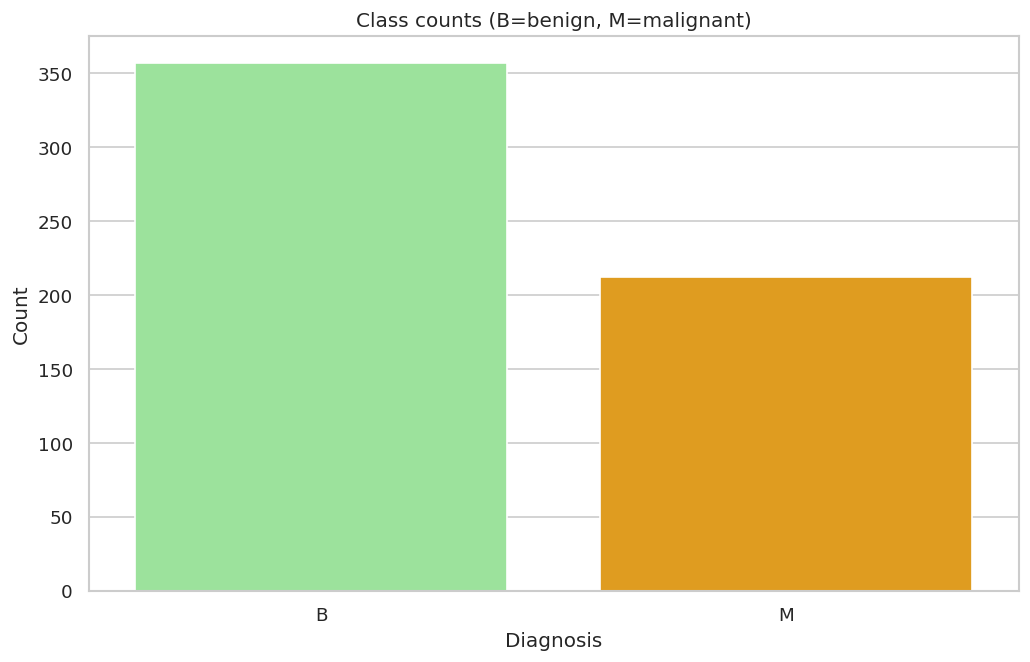

In [74]:
# Check class balance with count plot
df["diagnosis"].value_counts()

palette_bm = {"B": "lightgreen", "M": "orange"}

balance_plot = sns.countplot(data=df,
                             x="diagnosis",
                             hue="diagnosis",
                             palette=palette_bm,
                             order=["B", "M"],
                             legend=False)
balance_plot.set_title("Class counts (B=benign, M=malignant)")
balance_plot.set_xlabel("Diagnosis")
balance_plot.set_ylabel("Count")
plt.show()

As it can be seen on the previous plot, the class distribution is moderately imbalanced: benign cases are more frequent than malignant cases. This imbalance should be considered during modelling, since a classifier could obtain a high accuracy by favoring the majority class. For this reason, stratified splitting/cross-validation and metrics such as recall and F1 for the malignant class are especially important.

Next, histograms are plotted for all 30 numerical features to inspect their distributions. This helps identify ranges, skewness, and potential outliers, and supports preprocessing decisions such as whether scaling is needed before modelling.

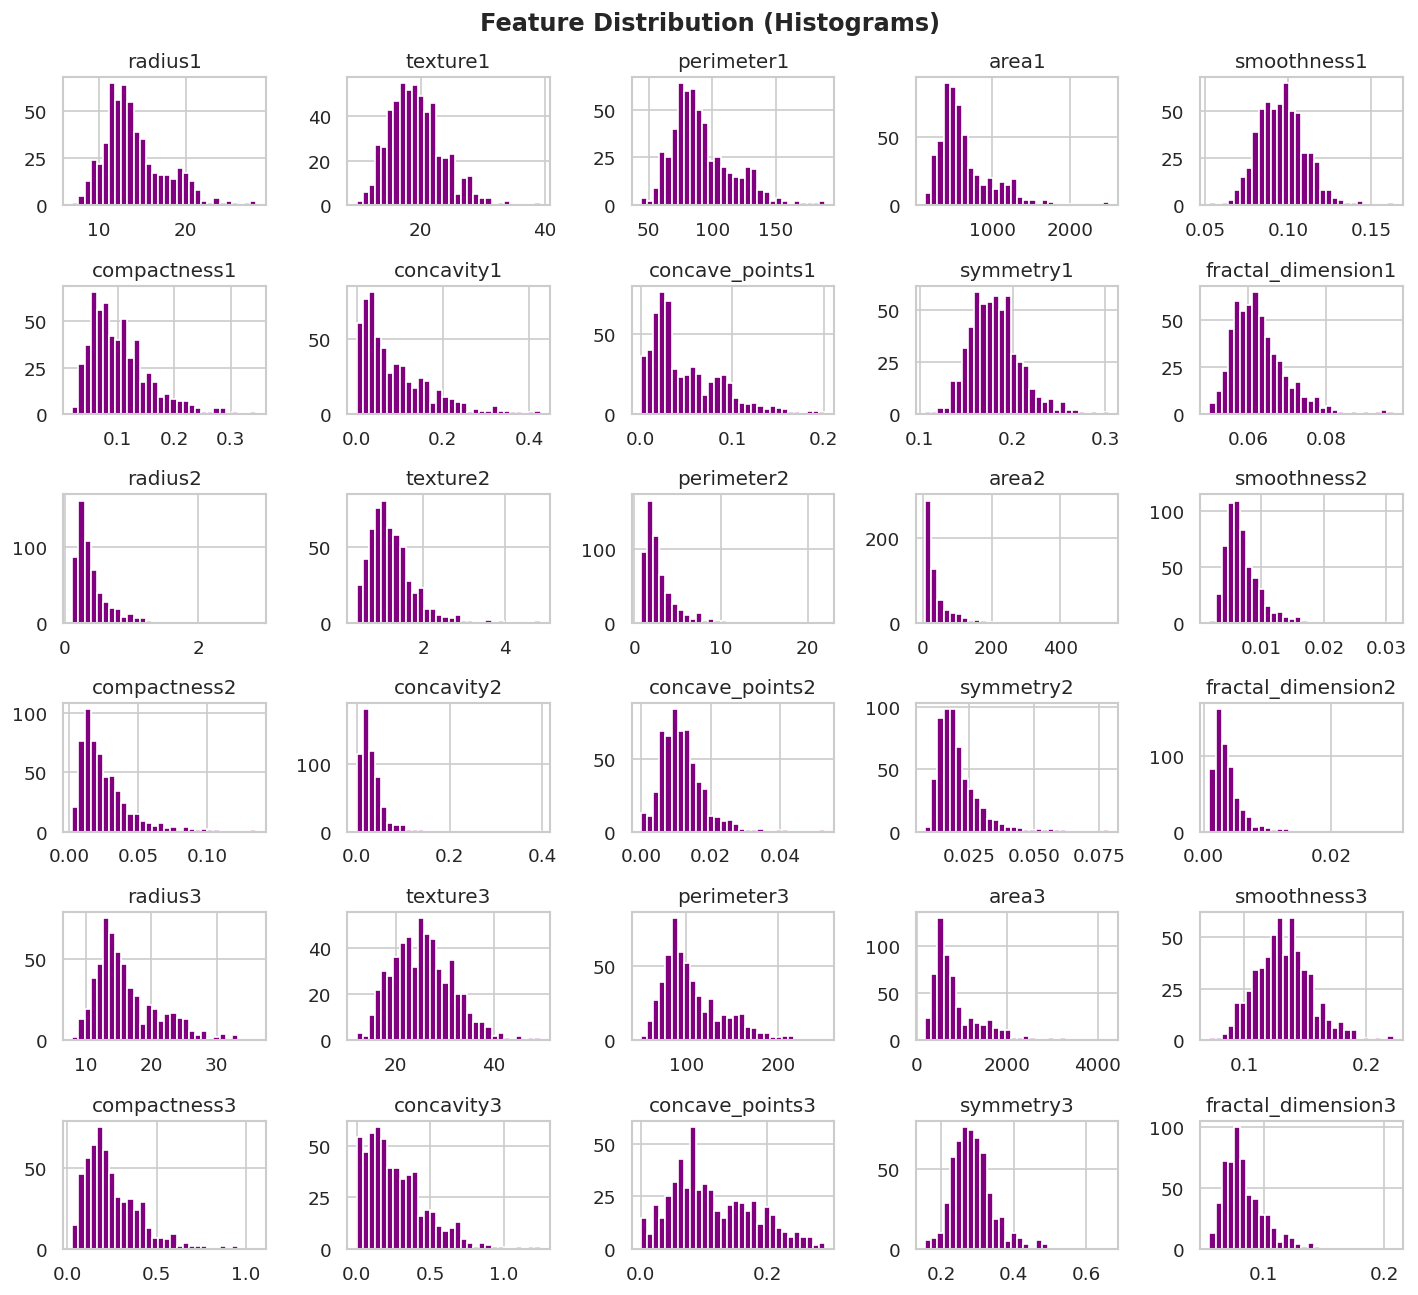

In [75]:
# Check distribution with histograms
hist_df = df.drop(columns=["diagnosis", "target"])
axes = hist_df.hist(
    bins=30,
    layout=(6, 5),
    figsize=(12, 11),
    color="purple",
    edgecolor="white")

plt.suptitle("Feature Distribution (Histograms)", fontweight="bold")
plt.tight_layout()
plt.show()

Overall, the histograms show that the 30 numerical features have very different scales and distribution shapes across the mean (1), SE (2), and “worst” (3) groups. Many size- and shape-related measurements (especially area and perimeter features) appear right-skewed with long tails, suggesting the presence of extreme values or outliers, and the “worst” features often show broader ranges. Since the predictors are heterogeneous and not normally distributed, applying feature scaling is important for models like Logistic Regression and SVM to behave properly.

While histograms show the full shape of each distribution, boxplots summarize each feature using quartiles and highlight potential outliers. This offers a compact way to compare variability across many features.

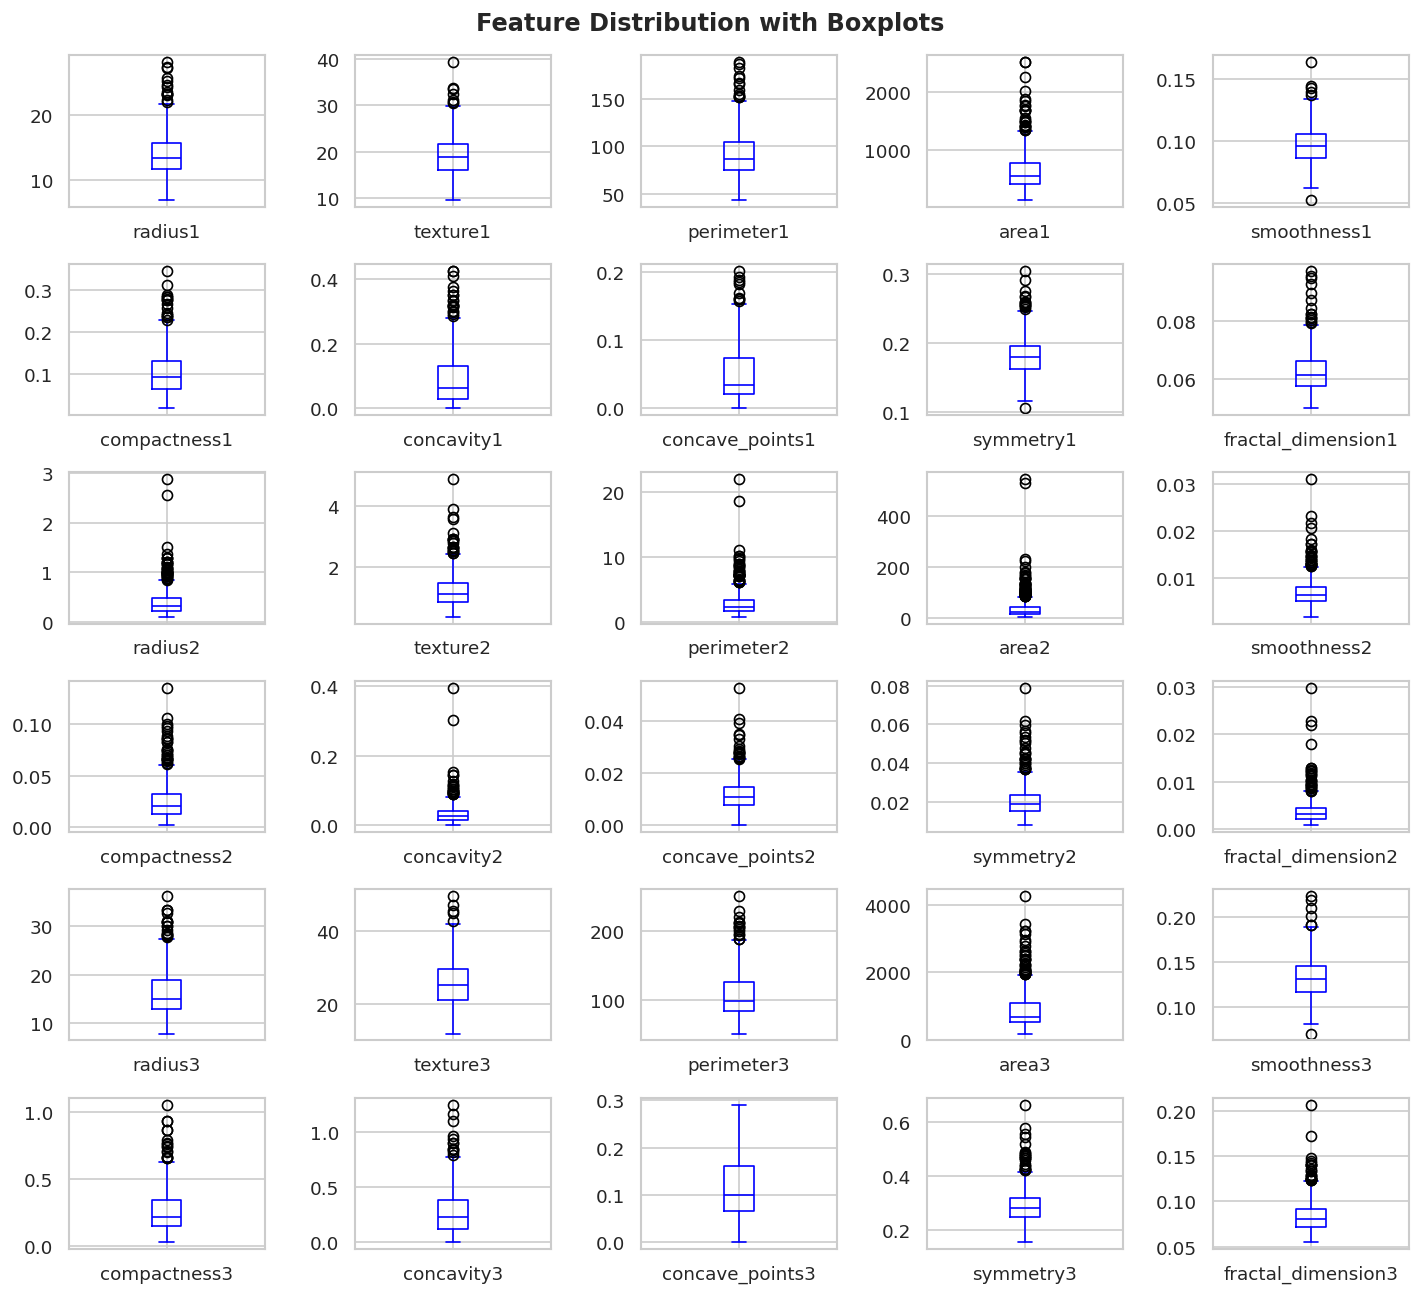

In [76]:
# Check distribution with boxplots
plot_df = df.drop(columns=["diagnosis", "target"])
axes = plot_df.plot(kind="box",
                    subplots=True,
                    layout=(6, 5),
                    color="blue",
                    figsize=(12, 11),
                    sharey=False)

plt.suptitle("Feature Distribution with Boxplots", fontweight="bold")
plt.tight_layout()
plt.show()

The boxplots confirm what the histograms suggested: the features have very different scales and many show strong skewness with numerous outliers. Size-related measurements (such as area and perimeter, especially the “worst” versions) have particularly long upper tails, while several texture/shape features show tighter central ranges but still include extreme values. This reinforces the need for feature scaling before training models like Logistic Regression and SVM, and it supports using feature selection and robust evaluation to reduce the impact of redundant or highly variable predictors.

A useful follow-up to the distribution analysis is building a correlation matrix, which is computed to measure how strongly pairs of numerical features are related. This is important for detecting redundancy, especially in this dataset where many variables are mean, SE, and “worst” versions of the same measurements. Identifying highly correlated features helps motivate feature selection or dimensionality reduction and supports more stable modelling.

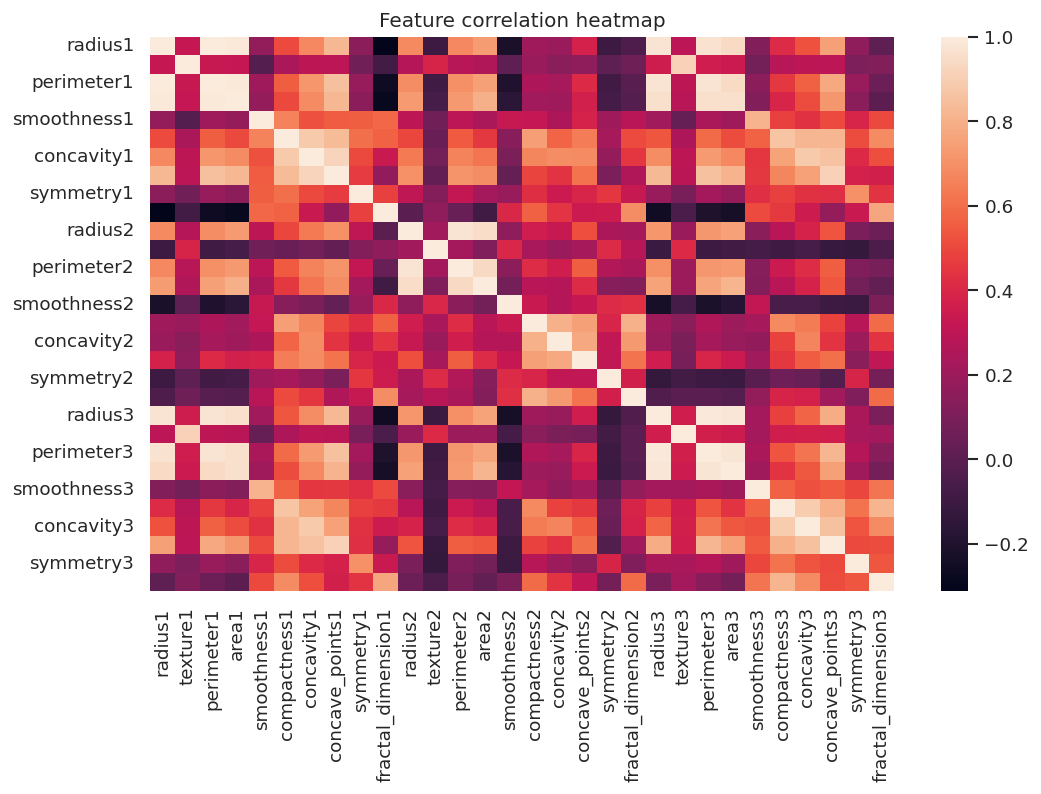

In [77]:
# Obtain correlation matrix
corr_feat = df.drop(columns=["diagnosis", "target"]).corr(numeric_only=True)

sns.heatmap(corr_feat, annot=False)
plt.title("Feature correlation heatmap")
plt.show()

To make the correlation analysis more significant, the strongest correlations are extracted as explicit feature pairs. While the full correlation matrix provides a global overview, extracting the top correlated pairs makes it easier to pinpoint specific sources of redundancy. Feature pairs above a high threshold (∣corr∣>0.90) often reflect measurements describing the same underlying property, so highlighting them supports later decisions such as removing redundant predictors or using feature selection to improve model stability.

In [78]:
# Identify highly correlated pairs
threshold = 0.90
corr_matrix = corr_feat.abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = (upper.stack().sort_values(ascending=False))

high_corr_pairs[high_corr_pairs > threshold].head(12)

,,0
radius1,perimeter1,0.997855
radius3,perimeter3,0.993708
radius1,area1,0.987357
perimeter1,area1,0.986507
radius3,area3,0.984015
perimeter3,area3,0.977578
radius2,perimeter2,0.972794
perimeter1,perimeter3,0.970387
radius1,radius3,0.969539
perimeter1,radius3,0.969476


The strongest correlations are observed among size-related features, especially combinations of radius, perimeter, and area. This is expected because these variables measure closely related aspects of nucleus size, so larger nuclei tend to have simultaneously higher radius, perimeter, and area. Overall, these results indicate substantial redundancy in the feature set and support the use of feature selection to improve model stability.

# Step 3: Data Preparation

Data preparation is an essential step in ML projects because it transforms the raw dataset into a form that can be used reliably for training and evaluation. This includes defining the predictor matrix and target labels, creating a train/test split to assess generalization on unseen data, and applying preprocessing decisions in a way that avoids data leakage. Preparing the data correctly ensures that model performance estimates are meaningful and that later steps such as feature selection, scaling, and cross-validation are applied consistently and fairly.

The modelling dataset is defined by separating predictors from labels: `X_model` contains only the numerical feature columns, while `y_model` contains the numeric target. The data is then split into training and test sets using a stratified split, which preserves the benign/malignant class proportions in both subsets. Finally, the shapes and class counts are printed to confirm that the split was performed correctly and that the test set remains representative of the original distribution.

In [79]:
from sklearn.model_selection import train_test_split

# Model-ready features/target (exclude the string label column)
X_model = df.drop(columns=["diagnosis", "target"])
y_model = df["target"]

# Stratified split to preserve class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model,
    test_size=0.2,
    stratify=y_model,
    random_state=RANDOM_STATE)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("\nTrain class counts:\n", y_train.value_counts())
print("\nTest class counts:\n", y_test.value_counts())

X_train: (455, 30) X_test: (114, 30)

Train class counts:
 target
0    285
1    170
Name: count, dtype: int64

Test class counts:
 target
0    72
1    42
Name: count, dtype: int64


Feature selection is applied to reduce redundancy in the predictor set and improve model stability. The correlation analysis showed that several variables are strongly related and often contain overlapping information, especially among size-related measurements and the mean/SE/worst summaries. Keeping many highly correlated predictors can make the model unnecessarily complex without adding much new signal.

To address this, a model-based feature selection approach is used: an ExtraTreesClassifier is trained on the training set to estimate feature importance, and SelectFromModel selects the most informative features using a simple threshold rule (`threshold="median"`), keeping roughly the top 50%. The selected subset is then applied consistently to the training, test, and modelling feature matrices before fitting the classifiers.

In [80]:
# Feature Selection
# (ExtraTrees importance + SelectFromModel)

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import SelectFromModel

# Fit importance model (only on train)
et = ExtraTreesClassifier(
    n_estimators=500,
    random_state=RANDOM_STATE,
    class_weight=None)
et.fit(X_train, y_train)

# Select features based on importance
selector = SelectFromModel(et, threshold="median", prefit=True)

selected_mask = selector.get_support()
selected_features = X_train.columns[selected_mask].tolist()

print(f"Features before: {X_train.shape[1]}")
print(f"Selected features: {len(selected_features)}")
print(selected_features)

# Apply selection to train/test and the full X_model used later
X_train = X_train[selected_features]
X_test  = X_test[selected_features]
X_model = X_model[selected_features]

print(f"Features after: {X_train.shape[1]}")

Features before: 30
Selected features: 15
['radius1', 'perimeter1', 'area1', 'compactness1', 'concavity1', 'concave_points1', 'area2', 'radius3', 'texture3', 'perimeter3', 'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3']
Features after: 15


Feature selection reduced the feature set from 30 to 15, keeping the most informative variables. The retained features mainly reflect nucleus size (radius/perimeter/area) and shape irregularity (compactness/concavity/concave points), which matches the earlier correlation findings and helps to improve the modelling step.

# Step 4: Baseline Model

A baseline model is trained first to establish a clear reference point before trying more complex approaches. **Logistic Regression** is a good baseline for binary classification because it is simple, fast to train, and often performs strongly. Building this initial pipeline helps verify that the full workflow works correctly (preprocessing, training, and evaluation) and provides a benchmark that later models and tuning steps can be compared against to measure whether they produce a meaningful improvement.

The baseline is implemented using a scikit-learn Pipeline, which applies `StandardScaler` to standardize the numerical features and then fits a `LogisticRegression` classifier. Using a pipeline ensures that preprocessing and modelling are combined into a single, reproducible object and prevents data leakage, since scaling parameters are learned only from the training data. Standardization is particularly important here because the features have different ranges, and Logistic Regression is sensitive to feature scale.

In [81]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Baseline pipeline
baseline_clf = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight=None,
        random_state=RANDOM_STATE))])

# Train baseline model
baseline_clf.fit(X_train, y_train)

print("Baseline model trained ✔")

Baseline model trained ✔


# Step 5: Evaluate Model

After training the baseline model, it is important to evaluate its performance on unseen data to understand how well it generalizes beyond the training set. This step measures how accurately the model distinguishes benign from malignant cases and highlights the types of errors it makes, which is especially relevant in a medical setting where false negatives are costly. The evaluation results provide a benchmark for comparing more advanced models and for deciding whether further tuning or modelling improvements are needed.

The baseline model is evaluated on the test set by generating predicted labels (`y_pred`) and predicted probabilities for the malignant class (`y_proba`). Performance is summarized with a classification report that provides precision, recall, and F1-score for each class. In addition, ROC-AUC is computed as a threshold-independent summary of how well the model separates benign and malignant samples based on predicted scores.

In [82]:
from sklearn.metrics import (confusion_matrix,
                             classification_report,
                             roc_auc_score,
                             RocCurveDisplay,
                             PrecisionRecallDisplay)

# Predictions
y_pred = baseline_clf.predict(X_test)
y_proba = baseline_clf.predict_proba(X_test)[:, 1]  # P(malignant=1)

# Text metrics
print("\nClassification Report:\n", classification_report(
    y_test, y_pred, target_names=["benign (0)", "malignant (1)"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


Classification Report:
                precision    recall  f1-score   support

   benign (0)       0.97      0.99      0.98        72
malignant (1)       0.98      0.95      0.96        42

     accuracy                           0.97       114
    macro avg       0.97      0.97      0.97       114
 weighted avg       0.97      0.97      0.97       114

ROC-AUC: 0.9798280423280423


The baseline Logistic Regression model already performs very well on the test set. Overall accuracy is 0.97 and ROC-AUC is ≈ 0.98. Precision and recall are high for both classes, with malignant recall around 0.95, meaning only a small number of malignant cases are missed. Overall, these results provide a strong baseline and show that even a simple linear model can achieve excellent performance on this dataset after scaling and feature selection.

The confusion matrix is then visualized as a heatmap to make the error pattern easier to interpret. This plot clearly shows how many samples were correctly classified and how many were misclassified, highlighting false positives and false negatives at a glance.

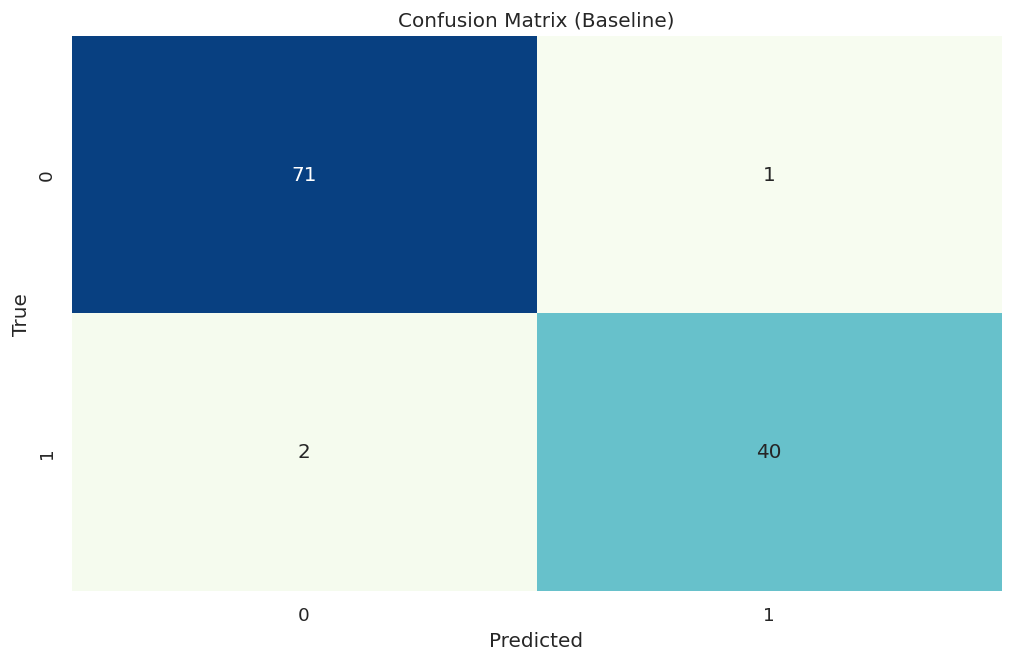

In [83]:
# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="GnBu", cbar=False)
plt.title("Confusion Matrix (Baseline)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

The confusion matrix confirms strong baseline performance. The model correctly classifies 71/72 benign cases and 40/42 malignant cases. It produces 1 false positive (benign predicted as malignant) and 2 false negatives (malignant predicted as benign), meaning malignant recall is high but not perfect.

The ROC curve (Receiver Operating Characteristic) visualizes how the classifier’s performance changes as the decision threshold is varied. It plots the True Positive Rate (recall/sensitivity) against the False Positive Rate, showing the trade-off between detecting malignant cases and generating false alarms. The ROC curve is useful because it evaluates the model across all possible thresholds rather than at a single cutoff, and the corresponding ROC-AUC provides a threshold-independent summary of how well the model separates benign and malignant samples.

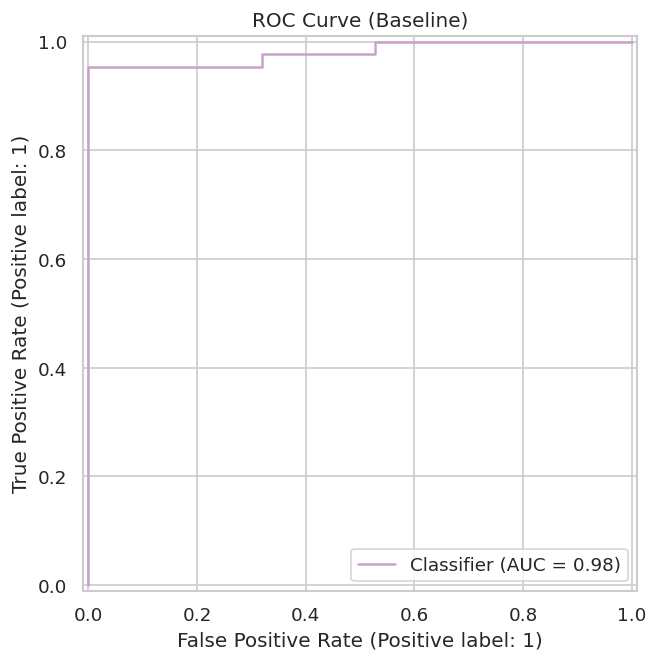

In [84]:
# ROC curve
lilac = "#c8a2c8"
roc_disp = RocCurveDisplay.from_predictions(y_test, y_proba)
roc_disp.line_.set_color(lilac)
plt.gca().legend(loc="lower right")
plt.title("ROC Curve (Baseline)")
plt.show()

This ROC curve shows very strong performance: the curve is close to the top-left corner and the AUC ≈ 0.98, indicating excellent separation between benign and malignant cases.

The Precision-Recall (PR) curve is plotted to evaluate how the model balances precision and recall for the malignant class across different decision thresholds. This visualization is especially useful in imbalanced classification problems because it focuses on performance for the positive class and highlights the trade-off between detecting more malignant cases (higher recall) and avoiding false alarms (higher precision).

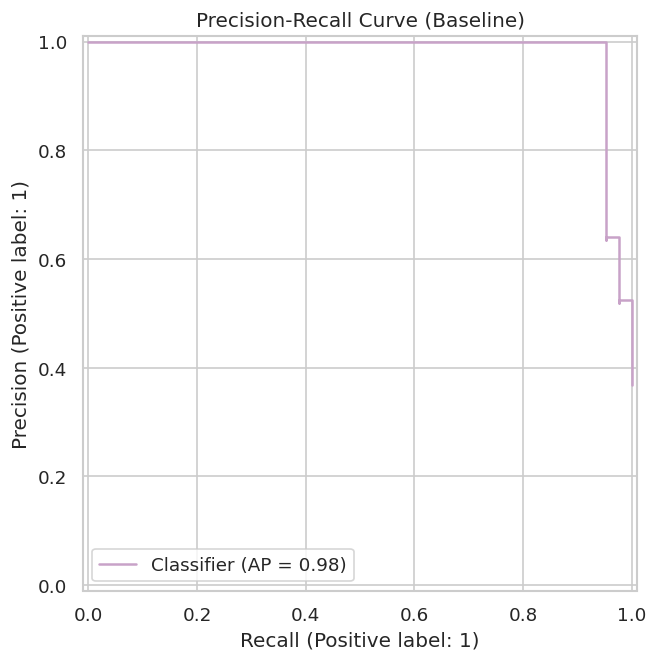

In [85]:
# Precision-Recall curve
pr_disp = PrecisionRecallDisplay.from_predictions(y_test, y_proba)
pr_disp.line_.set_color(lilac)
plt.gca().legend(loc="lower left")
plt.title("Precision-Recall Curve (Baseline)")
plt.show()

The Precision-Recall curve also shows very strong performance. The curve stays near the top of the plot for most thresholds and the Average Precision (AP) ≈ 0.98, indicating that the model maintains high precision while achieving high recall for malignant cases.

# Step 6: Cross-Validation

Cross-validation is used to obtain a more reliable estimate of model performance than a single train/test split. In k-fold cross-validation, the training data is divided into k subsets (folds); the model is trained on k-1 folds and evaluated on the remaining fold, repeating this process so each fold is used for validation once. This is important because performance on one test split can be affected by how the data happened to be divided, while cross-validation averages results across multiple splits and provides a mean ± standard deviation that reflects both performance and variability.

At this point in the workflow, cross-validation is performed after the baseline evaluation to confirm that the baseline results are consistent and to create a robust benchmark that can be used for fair comparison of different models and for hyperparameter tuning later.

A 5-fold StratifiedKFold cross-validation scheme is defined to keep the benign/malignant class proportions consistent in each fold. The baseline pipeline is then evaluated with `cross_validate` using multiple performance metrics (accuracy, precision, recall, F1, and ROC-AUC). For each metric, the mean and standard deviation across folds are printed to summarize both average performance and variability.

In [86]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(baseline_clf,
                            X_model, y_model,
                            cv=cv,
                            scoring=scoring,
                            return_train_score=False)

# Report CV results
for metric in scoring.keys():
    scores = cv_results[f"test_{metric}"]
    print(f"{metric}: {scores.mean():.3f} ± {scores.std():.3f}")

accuracy: 0.975 ± 0.017
precision: 0.986 ± 0.012
recall: 0.948 ± 0.046
f1: 0.966 ± 0.025
roc_auc: 0.995 ± 0.003


These cross-validation results indicate consistently strong performance. Accuracy is high (0.975 ± 0.017) and ROC-AUC is near perfect (0.995 ± 0.003), suggesting the model separates benign and malignant cases very well across folds. Precision is also very high (0.986 ± 0.012), meaning few benign samples are incorrectly predicted as malignant. Recall is slightly lower (0.948 ± 0.046) and shows more variability, which indicates that the number of missed malignant cases can change depending on the fold. Overall, the model is reliable, but improving malignant recall is the main area where further optimisation could be beneficial.

# Step 7: Feature Importance

Feature importance is examined to make the baseline model more interpretable and to understand which measurements contribute most to the classification. For Logistic Regression, this can be done by inspecting the learned coefficients: after standardization, larger absolute coefficient values indicate a stronger influence on the prediction. Plotting the top coefficients provides a clear summary of the features that the model relies on most, and helps connect the ML results back to meaningful nucleus properties.

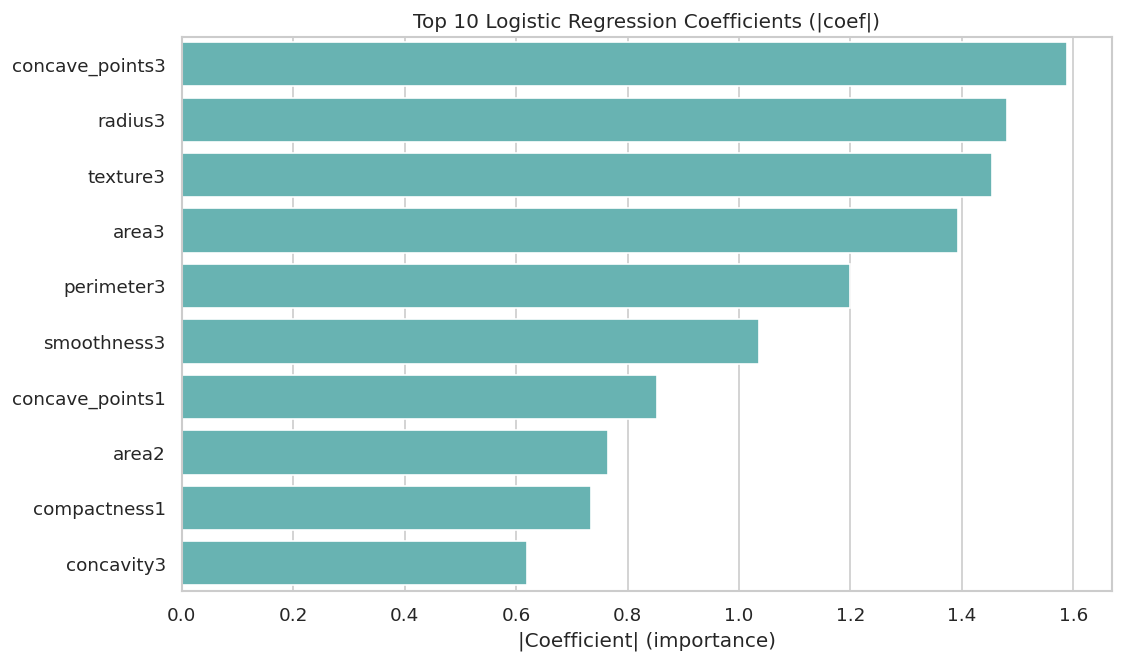

In [87]:
# Get feature names and coefficients from the trained baseline model
feature_names = X_train.columns
coefs = baseline_clf.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs)
}).sort_values("abs_coef", ascending=False)

# Plot top 10 most important features (by absolute coefficient)
top_n = 10
sns.barplot(data=coef_df.head(top_n),
            x="abs_coef",
            y="feature",
            color="#5bc0be")

plt.title(f"Top {top_n} Logistic Regression Coefficients (|coef|)")
plt.xlabel("|Coefficient| (importance)")
plt.ylabel("")
plt.show()

The plot shows that the baseline Logistic Regression model relies most strongly on shape irregularity and size-related “worst” measurements. Features such as `concave_points3`, `radius3`, `texture3`, `area3`, and `perimeter3` have the largest coefficient magnitudes, suggesting that more extreme nucleus characteristics are particularly informative for distinguishing malignant from benign cases. The presence of multiple “worst” features among the top predictors is consistent with the idea that malignant tumors tend to exhibit more irregular and extreme morphological properties.

# Step 8: Compare Models

In this step, multiple classification algorithms are compared to identify the most suitable model for the task. Using the same 5-fold Stratified Cross-Validation setup ensures a fair comparison by evaluating each model on consistent splits that preserve the benign/malignant class proportions. Three common classifiers are tested: **Logistic Regression** (a strong linear baseline), **SVM with RBF kernel** (a non-linear model), and **k-Nearest Neighbors** (a distance-based method).

In [88]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Logistic Regression
models = []
models.append(("LogReg", Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, class_weight=None, random_state=RANDOM_STATE))])))

# Support Vector Machine (RBF Kernel)
models.append(("SVM (RBF)", Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", class_weight=None, random_state=RANDOM_STATE))])))

# k-Nearest Neighbors
models.append(("kNN", Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))])))

Performance is summarized across folds to assess both average accuracy and variability, helping guide the selection of the best candidate for further tuning.

In [89]:
# Summarize cross-validation performance for each model
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}
rows = []
for name, model in models:
    cv_res = cross_validate(model, X_model, y_model, cv=cv, scoring=scoring)
    rows.append({
        "model": name,
        **{m: f"{cv_res[f'test_{m}'].mean():.3f} ± {cv_res[f'test_{m}'].std():.3f}" for m in scoring}})

pd.DataFrame(rows)

,model,accuracy,precision,recall,f1,roc_auc
0,LogReg,0.975 ± 0.017,0.986 ± 0.012,0.948 ± 0.046,0.966 ± 0.025,0.995 ± 0.003
1,SVM (RBF),0.972 ± 0.007,0.972 ± 0.017,0.953 ± 0.034,0.962 ± 0.010,0.995 ± 0.003
2,kNN,0.965 ± 0.017,0.962 ± 0.019,0.943 ± 0.039,0.952 ± 0.023,0.987 ± 0.011


The cross-validation results show that **Logistic Regression and SVM (RBF)** are the strongest models overall, with very similar accuracy and ROC-AUC (~0.995), indicating excellent separability between classes. Logistic Regression achieves the highest mean accuracy and precision, while SVM provides the **best mean recall** for the malignant class, **which is important when prioritizing detection of malignant tumors.** kNN performs slightly worse across most metrics and has a noticeably lower ROC-AUC, suggesting weaker overall discrimination compared to LogReg and SVM.

To complement the numerical cross-validation summary, boxplots are used to visualize the distribution of model scores across the cross-validation folds. This makes it easier to compare not only average performance, but also how stable each model is, since a wider spread indicates higher variability between folds.

In [90]:
# Build a long-format CV results table (scores_df) to enable boxplot visualization
scoring = {"accuracy":"accuracy","precision":"precision","recall":"recall","f1":"f1","roc_auc":"roc_auc"}

long_rows = []
for name, model in models:
    cv_res = cross_validate(model, X_model, y_model, cv=cv, scoring=scoring)
    for metric in scoring:
        for s in cv_res[f"test_{metric}"]:
            long_rows.append({"model": name, "metric": metric, "score": s})

scores_df = pd.DataFrame(long_rows)

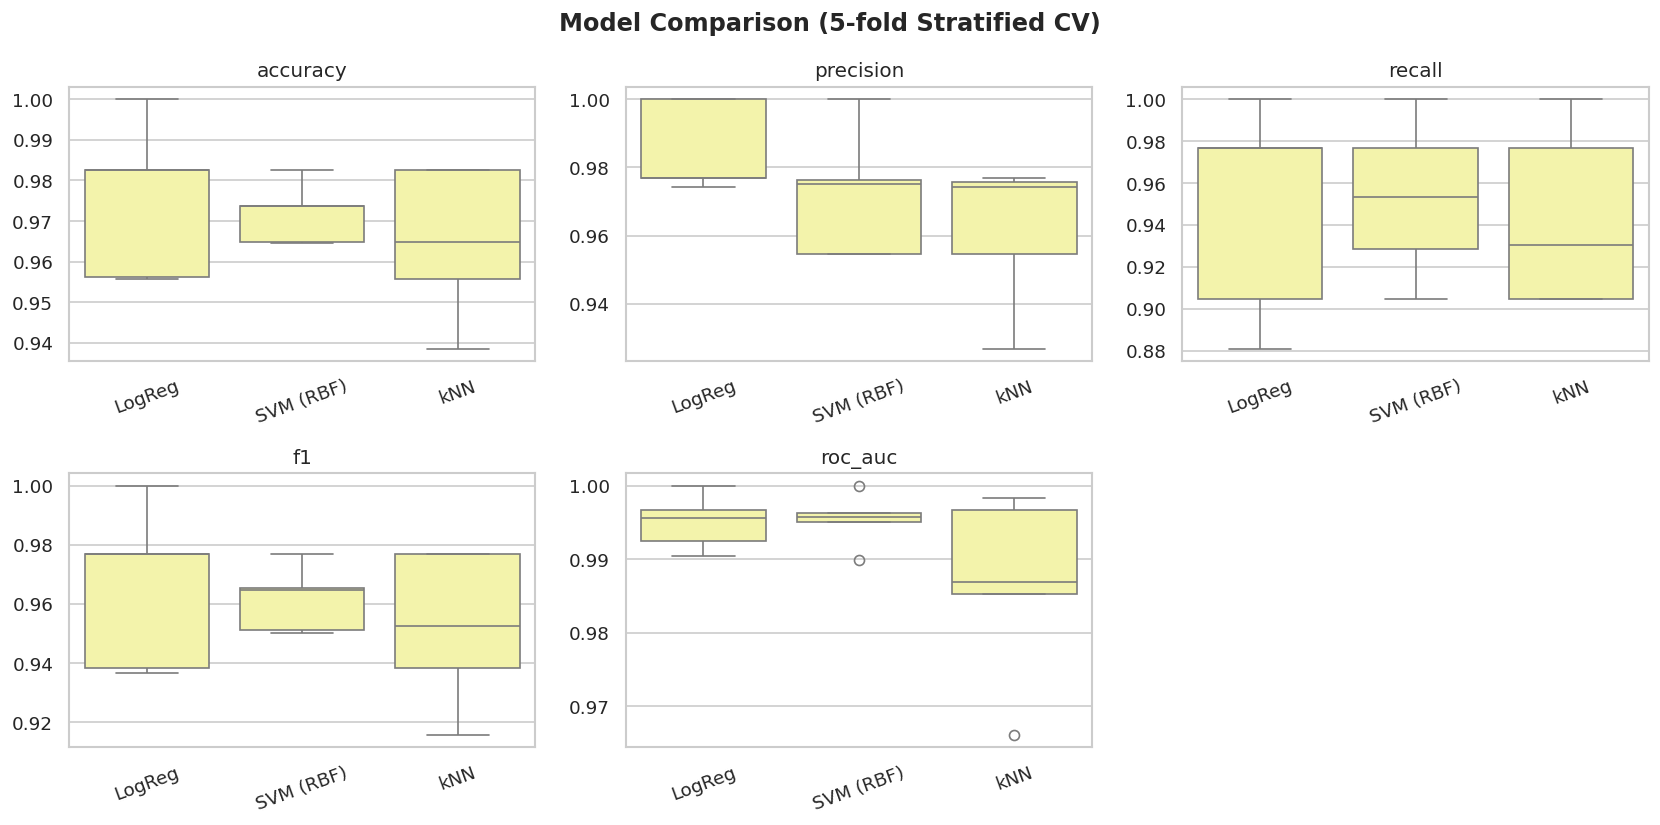

In [91]:
# Boxplot visualization of cross-validation performance for each model
metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(data=scores_df[scores_df["metric"] == metric],
                x="model", y="score",
                color="#ffff9f",
                ax=ax)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=20)
fig.delaxes(axes[-1])

plt.suptitle("Model Comparison (5-fold Stratified CV)", fontweight="bold")
plt.tight_layout()
plt.show()

The boxplots confirm that **Logistic Regression and SVM (RBF)** perform best across the metrics, while kNN is slightly weaker and more variable. Logistic Regression shows the highest precision and strong overall performance, but its recall and F1 vary more across folds, indicating less stable sensitivity to malignant cases depending on the split. SVM (RBF) has slightly lower precision than LogReg, but recall is strong and relatively stable, which supports its selection when prioritizing malignant detection. For ROC-AUC, both LogReg and SVM are consistently very high and tightly distributed, while kNN shows a lower median and wider spread, suggesting reduced class separability.

Given the objective of maximizing detection of malignant tumors, the **SVM (RBF) model** is selected as the most suitable candidate for hyperparameter tuning. Although Logistic Regression slightly edges SVM on accuracy and precision, SVM provides the highest average malignant recall and more stable performance across folds, making it the best starting point to tune key hyperparameters (such as `C` and `gamma`) with the goal of further improving sensitivity to malignant cases.

# Step 9: Hyperparameter Tuning

Hyperparameter tuning is the process of improving a model by searching for the best values of key settings that are not learned automatically during training. These hyperparameters control model complexity and can strongly affect both performance and generalization. Tuning is performed using cross-validation to ensure the chosen configuration works well across different data splits, and it helps refine the selected model beyond its default parameters before evaluating it on the final test set.

The tuning is performed for the selected **SVM (RBF) model** using GridSearchCV with 5-fold Stratified Cross-Validation to find the best combination of the key SVM parameters `C` (regularization strength) and `gamma` (kernel influence). The search is optimized for cross-validated **accuracy**, because using **recall** as the tuning objective reduced overall generalization performance in this setting. The model is tuned within a pipeline that includes feature standardization to ensure stable training. The best parameter set and corresponding CV accuracy are reported, and a heatmap of mean CV accuracy across the parameter grid is plotted to visualize how performance varies with different `C`/`gamma` values.

Best params: {'model__C': 10, 'model__gamma': 0.01}
Best CV accuracy: 0.9780219780219781


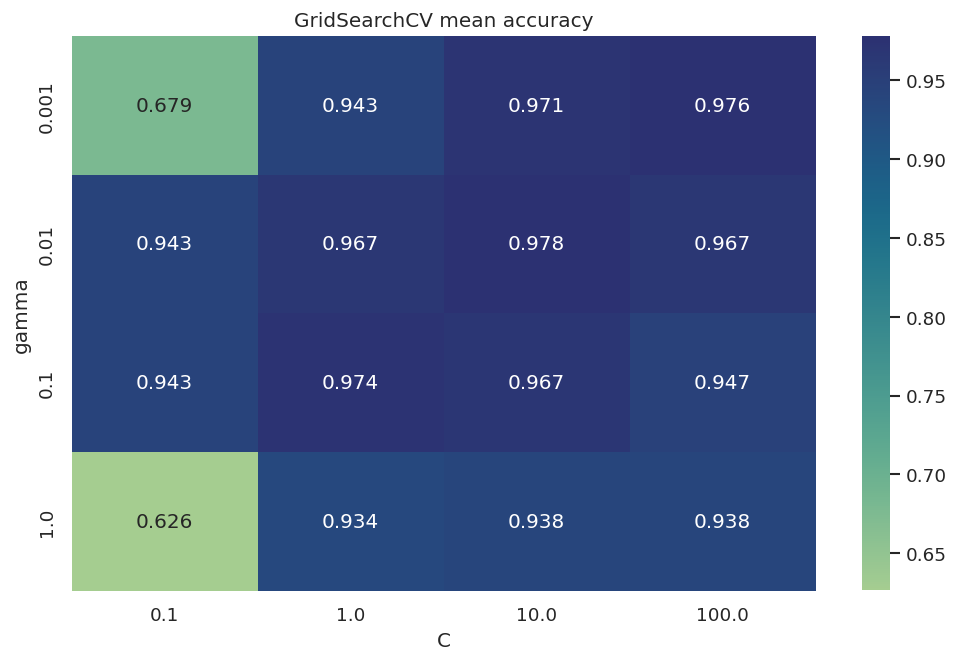

In [92]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# SVM (RBF)
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", class_weight=None, random_state=RANDOM_STATE))])

# Define hyperparameters for grid-search
param_grid = {
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": [0.001, 0.01, 0.1, 1]
}

# Run the search on the training set
grid = GridSearchCV(estimator=svm_pipe,
                    param_grid=param_grid,
                    scoring="accuracy",
                    cv=cv,
                    n_jobs=-1)

grid.fit(X_train, y_train)

# Report best hyperparameters and their performance
print("Best params:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

# Store best tuned model
best_svm = grid.best_estimator_

# Visualize grid search scores
res = pd.DataFrame(grid.cv_results_)
pivot = res.pivot_table(values="mean_test_score",
                        index="param_model__gamma",
                        columns="param_model__C")

sns.heatmap(pivot, annot=True, fmt=".3f", cmap="crest")
plt.title("GridSearchCV mean accuracy")
plt.xlabel("C")
plt.ylabel("gamma")
plt.show()

# Step 10: Evaluate tuned SVM on Test Set

The tuned SVM model is evaluated on the held-out test set to estimate how well it generalizes to unseen data. Class predictions are generated and combined with continuous model scores (using `predict_proba` when available, otherwise `decision_function`) to compute key performance metrics.

In [93]:
from sklearn.metrics import (confusion_matrix,
                             classification_report,
                             recall_score,
                             roc_auc_score,
                             RocCurveDisplay,
                             PrecisionRecallDisplay)

# Predictions
y_pred_svm_tuned = best_svm.predict(X_test)

# Scores for ROC/PR:
if hasattr(best_svm, "predict_proba"):
    y_score_svm_tuned = best_svm.predict_proba(X_test)[:, 1]
else:
    y_score_svm_tuned = best_svm.decision_function(X_test)

# Classification Report
print("\nClassification Report:\n", classification_report(
    y_test, y_pred_svm_tuned, target_names=["benign (0)", "malignant (1)"]))
print("Test ROC-AUC:", roc_auc_score(y_test, y_score_svm_tuned))


Classification Report:
                precision    recall  f1-score   support

   benign (0)       0.97      1.00      0.99        72
malignant (1)       1.00      0.95      0.98        42

     accuracy                           0.98       114
    macro avg       0.99      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114

Test ROC-AUC: 0.9837962962962963


Cross-validation was used to estimate performance more reliably across multiple splits, while the test set was kept as a final hold-out evaluation. The tuned SVM shows test-set performance that is broadly consistent with the cross-validation results, indicating good generalization and limited overfitting.

Overall accuracy is 0.98 and ROC-AUC is ≈ 0.984, indicating excellent separation between benign and malignant cases. Precision for the malignant class is 1.00, meaning all samples predicted as malignant were correct (no false positives), while malignant recall is 0.95, showing that only a small number of malignant cases were missed. Overall, the results suggest strong generalization with a good balance between sensitivity and avoiding false alarms.

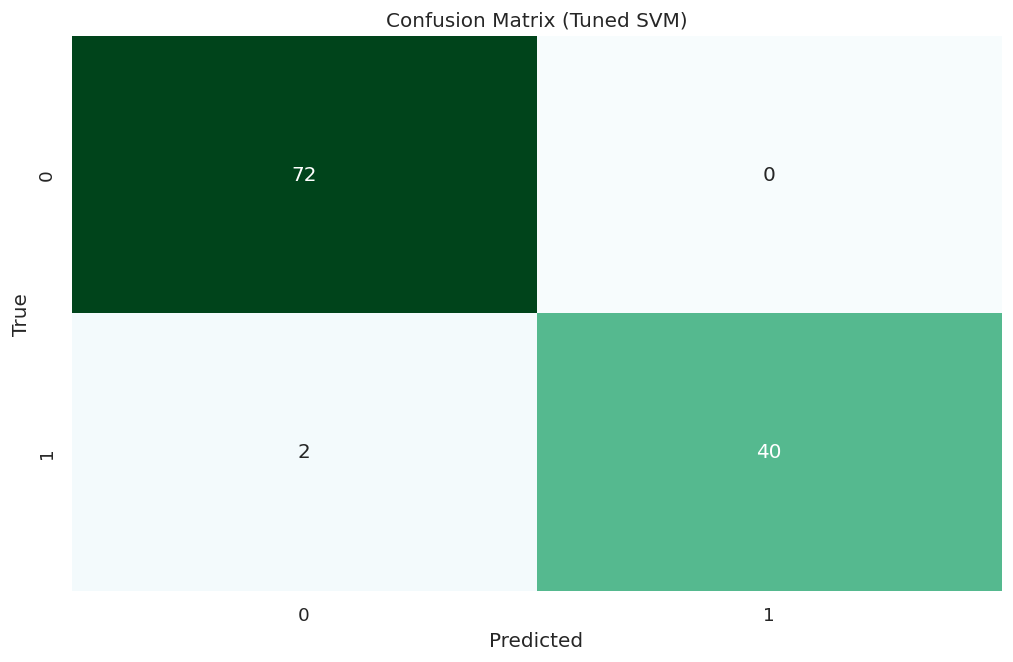

In [94]:
# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred_svm_tuned)
sns.heatmap(cm, annot=True, fmt="d", cmap="BuGn", cbar=False)
plt.title("Confusion Matrix (Tuned SVM)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

The confusion matrix shows that the tuned SVM correctly classifies 72/72 benign cases (no false positives) and 40/42 malignant cases. Only 2 malignant samples are misclassified as benign (false negatives), which explains why malignant recall is high but not perfect. Overall, the model achieves very strong performance with an especially low false-alarm rate while still detecting almost all malignant cases.

**Recall for the malignant class** is important in this model because it measures how many truly malignant cases it correctly identifies. In this task, a false negative (predicting benign when the tumor is malignant) is typically the most costly error, since it could delay diagnosis and treatment. A recall of 0.952 means the model detects about 95% of malignant cases in the test set, so only a small number of malignant tumors are missed.

In [95]:
# Key metric: recall for malignant (1)
print("Test Recall (malignant=1):", recall_score(y_test, y_pred_svm_tuned))

Test Recall (malignant=1): 0.9523809523809523


The ROC and Precision-Recall curves are plotted to visualize how well the tuned model separates benign and malignant cases across different decision thresholds:

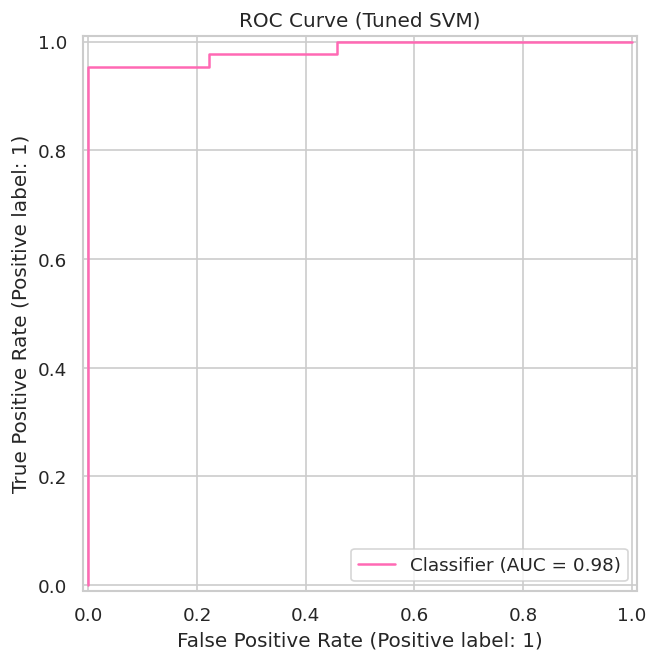

In [96]:
# ROC curve
roc_disp = RocCurveDisplay.from_predictions(y_test, y_score_svm_tuned)
roc_disp.line_.set_color("hotpink")
plt.gca().legend(loc="lower right")
plt.title("ROC Curve (Tuned SVM)")
plt.show()

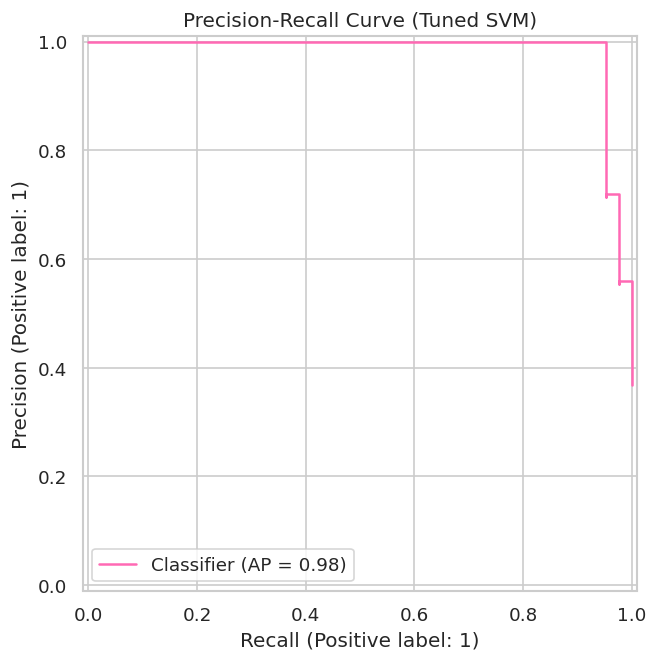

In [97]:
# Precision-Recall curve
pr_disp = PrecisionRecallDisplay.from_predictions(y_test, y_score_svm_tuned)
pr_disp.line_.set_color("hotpink")
plt.gca().legend(loc="lower left")
plt.title("Precision-Recall Curve (Tuned SVM)")
plt.show()

Both curves indicate excellent discrimination on the test set. The ROC curve stays close to the top-left corner with AUC ≈ 0.98, showing that the model separates benign and malignant samples very well across thresholds. The Precision-Recall curve is also strong with AP ≈ 0.98, meaning the model maintains high precision while achieving high recall for the malignant class, which is especially relevant given the class imbalance and the importance of correctly detecting malignant cases.

Finally, the baseline SVM and the tuned SVM are compared on the same test set using a consistent set of metrics. This side-by-side summary makes it clear whether hyperparameter tuning produced a meaningful improvement in performance.

In [98]:
from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             roc_auc_score,
                             confusion_matrix)

# Comparison between the baseline SVM and the tuned SVM
svm_pipe.fit(X_train, y_train)

def summarize(name, y_true, y_pred, y_score):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision(1)": precision_score(y_true, y_pred),
        "recall(1)": recall_score(y_true, y_pred),
        "f1(1)": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_score),
        "FN": fn,
        "FP": fp
    }

# Baseline SVM
y_pred_base = svm_pipe.predict(X_test)
y_score_base = (svm_pipe.predict_proba(X_test)[:, 1]
                if hasattr(svm_pipe, "predict_proba")
                else svm_pipe.decision_function(X_test))

# Tuned SVM
y_pred_tuned = best_svm.predict(X_test)
y_score_tuned = (best_svm.predict_proba(X_test)[:, 1]
                 if hasattr(best_svm, "predict_proba")
                 else best_svm.decision_function(X_test))

comparison = pd.DataFrame([
    summarize("Baseline SVM (svm_pipe)", y_test, y_pred_base, y_score_base),
    summarize("Tuned SVM (best_svm)", y_test, y_pred_tuned, y_score_tuned),])

comparison

,model,accuracy,precision(1),recall(1),f1(1),roc_auc,FN,FP
0,Baseline SVM (svm_pipe),0.964912,0.952381,0.952381,0.952381,0.983466,2,2
1,Tuned SVM (best_svm),0.982456,1.000000,0.952381,0.975610,0.983796,2,0


The tuned SVM improves overall test performance compared to the baseline. Accuracy increases from 0.9649 to 0.982 and the malignant-class F1-score increases from 0.952 to 0.976. Malignant recall remains unchanged (0.952, with FN = 2 for both models), meaning the number of missed malignant cases did not decrease. However, tuning eliminates false positives (FP: 2 → 0), which raises malignant precision from 0.952 to 1.000. ROC-AUC is essentially unchanged (~0.984), indicating similar class separability while tuning improves the error balance by reducing false alarms without increasing false negatives.

#**Conclusion**

The final results show that the models perform very well on this dataset. Logistic Regression and SVM achieved similarly high cross-validated accuracy and ROC-AUC, while kNN showed lower performance across the reported metrics. Since the main goal is to avoid missing malignant tumors, recall for the malignant class was treated as the priority metric. SVM (RBF) provided the highest and most stable recall in cross-validation, so it was selected for tuning. After tuning, test-set performance improved mainly by reducing false positives (higher precision and accuracy), while the number of false negatives remained the same, so malignant recall stayed essentially unchanged.

Overall, the project aims were fulfilled: class imbalance was handled using stratified evaluation and appropriate model settings, and feature redundancy/correlation was addressed through exploratory analysis and feature selection. The resulting pipeline demonstrates a realistic machine learning workflow applied to a healthcare classification task, illustrating how ML can support medical decision-making by distinguishing malignant from benign cases using biopsy-derived measurements.

A potential next improvement might be to optimize the decision threshold to trade off false negatives versus false positives, and to explore a wider hyperparameter search space or alternative feature-selection strategies to further enhance malignant detection.